# Initial Design 

Similar to the 2D case, before running the optimizations, we want to look at the initial design and check the gradients. Below we import the previously computed parameters and analyze 

In [5]:
import autograd.numpy as np 
import matplotlib.pyplot as plt
import autograd.numpy as anp
from autograd import value_and_grad

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency,
                    R, r0_extra, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, wl_range,
                    to_substrate)

We will look at just the initial 2D optimization here since the stochastic optimization should be similar for the purpose of this notebook. First we get the parameters from the first optimization

In [2]:
# load files later for us
def load_history(filename):
    with open(filename, "rb") as f:
        file = pickle.load(f)
    return file

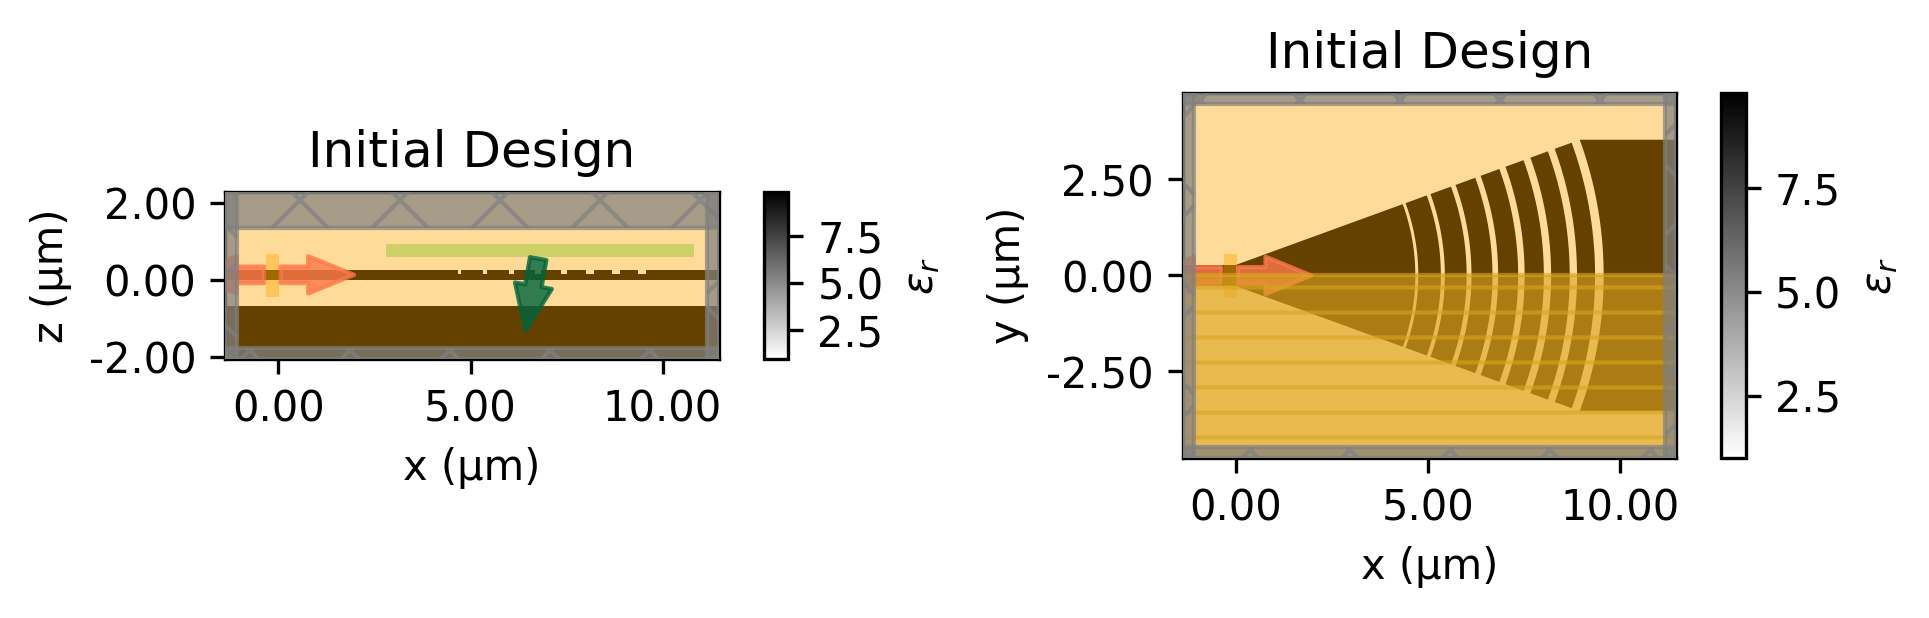

In [6]:
data = load_history("../GC_4um_2D/data/opt/history.pkl")
params = data['history']['params'][-1]

# make the grating structure
widths = params[:-3]
r0 = params[-3] + r0_extra
etch_depth = params[-2]
to_substrate = params[-3]

# make the simulation
sim = make_sim(widths, r0=r0, to_substrate=to_substrate, etch_depth=etch_depth, include_field_monitor=True)

# plot the structure
fig,ax = plt.subplots(1,2,dpi=300)
sim.plot_eps(y=0,ax=ax[0])
sim.plot_eps(z=.15,ax=ax[1])
ax[0].set_title("Initial Design")
ax[1].set_title("Initial Design")
plt.tight_layout()
plt.show()

In [7]:
# run the simulation
sim_data = web.run(sim, task_name="GC4um_3D_test", verbose=False, path="data/tidy3d_output/tmp.hdf5")

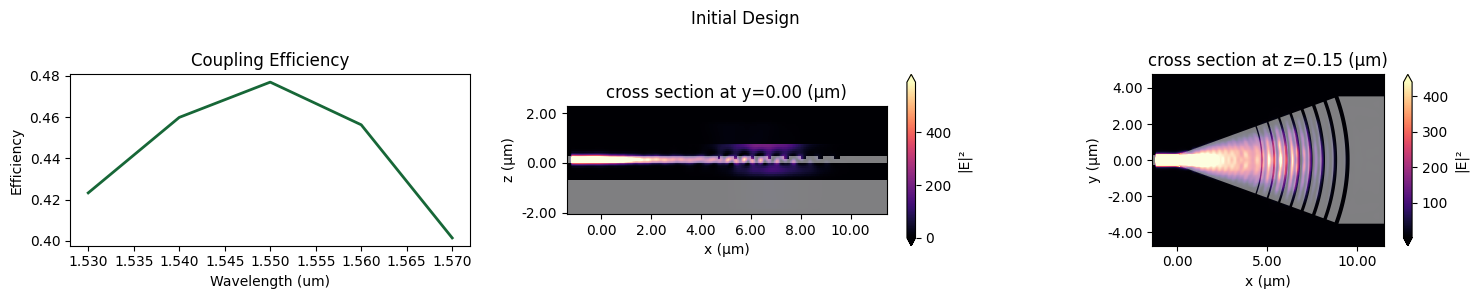

In [8]:
# compute the coupling efficiency
coupling = get_coupling_efficiency(sim_data)

# Plot the coupling efficiency and the field next to each other
fig, axs = plt.subplots(1, 3, figsize=(15, 3))
fig.suptitle("Initial Design")

# Coupling efficiency plot
axs[0].plot(wl_range, coupling, linewidth=2)
axs[0].set_title("Coupling Efficiency")
axs[0].set_xlabel("Wavelength (um)")
axs[0].set_ylabel("Efficiency")

# Field plot along the center of the waveguide
sim_data.plot_field("field", "E", "abs^2", y=0, ax=axs[1], eps_alpha=0.5)

# Field plot across the whole grating structure 
sim_data.plot_field("field", "E", "abs^2", z=.15, ax=axs[2], eps_alpha=0.5)

plt.tight_layout()
plt.show()

We lost some coupling, as is expected, going from 2D to 3D.

# Check the Gradients

Similar to the 2D case, we need to check the gradeints found with automatic differentiation againt finite difference gradients. To do this we set up the same objective as before. 

In [11]:
# define the objective as the average coupling efficiency across the wavelength range
def objective(params):

    # pull out the different parameters
    widths = params[:-3]
    r0 = params[-3]
    etch_depth = params[-2]
    to_substrate = params[-1]

    # make the simulation
    sim = make_sim(widths, r0=r0, to_substrate=to_substrate, etch_depth=etch_depth, include_field_monitor=False)

    # run the simulation
    sim_data = web.run(sim, task_name="GC4um_3D_test", verbose=False, path="data/tidy3d_output/tmp.hdf5")

    # compute the coupling efficiency
    coupling = get_coupling_efficiency(sim_data)

    # return the average coupling efficiency
    return anp.mean(coupling)

# make the list of our initial parameters
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])

Check the gradients using autograd

In [12]:
# compute the gradient of the objective using autograd
grad_objective = value_and_grad(objective)

# compute the gradient of the objective at the initial parameters
value_params0, grad_params0 = grad_objective(params0)

To compute the gradients with automatic differentiation, we run a batch of simulations with each parameter slightly changed. 

This is a fairly costly simulation, but it is work it to assure our optimization runs correctly.

In [13]:
# change each parameter by 5nm
dp = .001

# make a batch run with one parameter perturbed at a time
batch_sims = {}
for i in range(len(params0)):
    params = np.array(params0, copy=True)
    params[i] += dp
    batch_sims[f"p"+str(i)] = make_sim(params[:-3], r0=params[-3], etch_depth=params[-2], to_substrate=params[-1], include_field_monitor=False)
batch = web.Batch(simulations=batch_sims,verbose=True)

# run the batch
batch_data = batch.run(path_dir="data/tidy3d_output")



Output()

13:54:25 EDT Started working on Batch containing 19 tasks.

13:54:56 EDT Maximum FlexCredit cost: 3.368 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

13:56:28 EDT Batch complete.

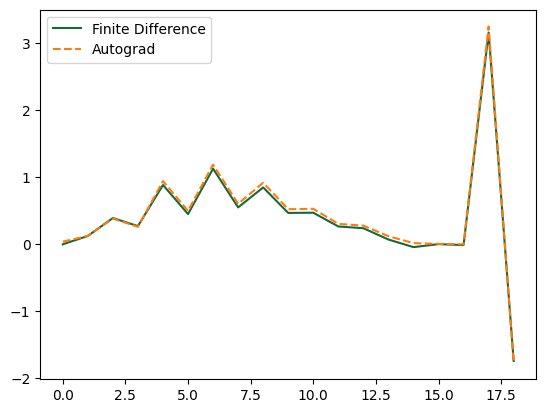

In [14]:
#compute the gradiend using finite difference
grad_fd = np.zeros(len(params0))
for i in range(len(params0)):
    J_pert = np.mean(get_coupling_efficiency(batch_data[f"p"+str(i)]))
    grad_fd[i] = (J_pert - value_params0) / dp

#compare the two gradients in a figure 
plt.plot(grad_fd, label="Finite Difference")
plt.plot(grad_params0,'--', label="Autograd")
plt.legend()
plt.show()

The gradients match well, so we can move to optimization.